In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

In [6]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sector = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

txn = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

perf = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

In [7]:
print(fund.columns)
print(nav.columns)
print(sip.columns)
print(txn.columns)
print(perf.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')
Index(['amfi_code', 'date', 'nav'], dtype='object')
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 

Chart 1: NAV Trend Analysis (Plotly)

In [8]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

In [9]:
import plotly.io as pio

pio.write_image(
    fig,
    "../reports/nav_trend.png",
    format="png"
)

Chart 2: Top 10 Funds by Average NAV

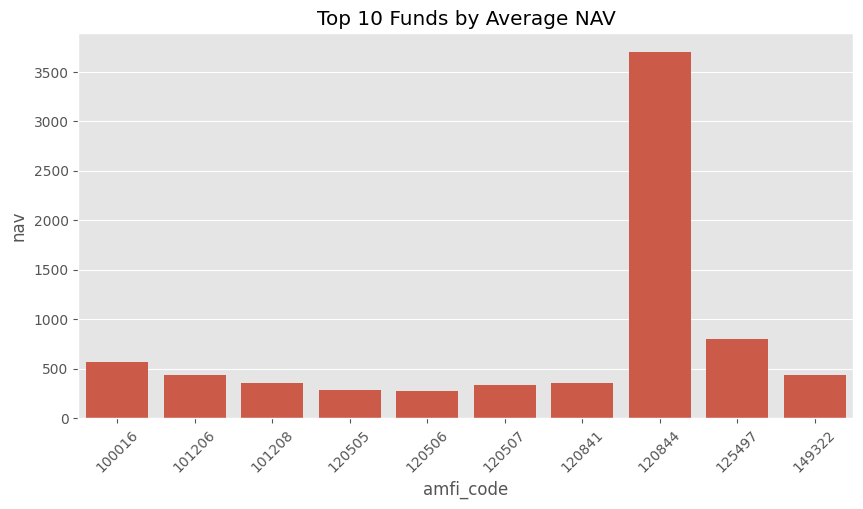

In [10]:
avg_nav = (
    nav.groupby("amfi_code")["nav"]
    .mean()
    .reset_index()
    .sort_values("nav", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(data=avg_nav, x="amfi_code", y="nav")
plt.title("Top 10 Funds by Average NAV")
plt.xticks(rotation=45)
plt.show()

Chart 3: SIP Inflow Trend

In [14]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_aum_lakh_crore",
    title="Monthly SIP AUM Growth"
)

fig.show()

Chart 4: SIP Account Growth

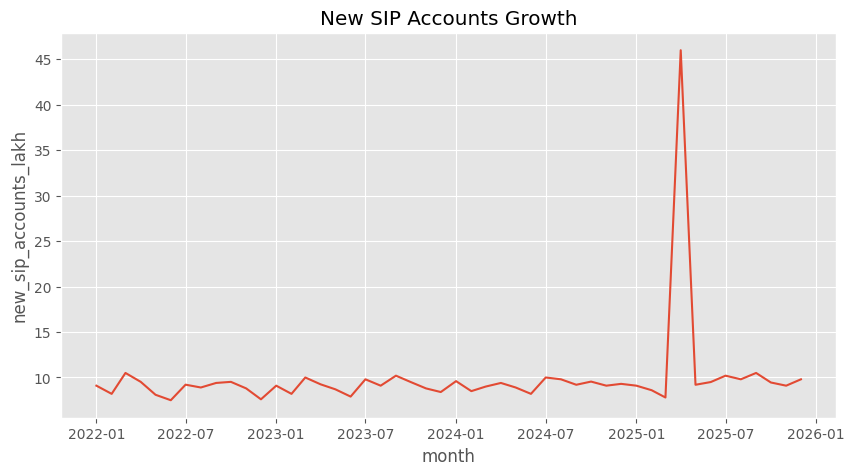

In [12]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=sip,
    x="month",
    y="new_sip_accounts_lakh"
)

plt.title("New SIP Accounts Growth")
plt.show()

Chart 5: Category Distribution

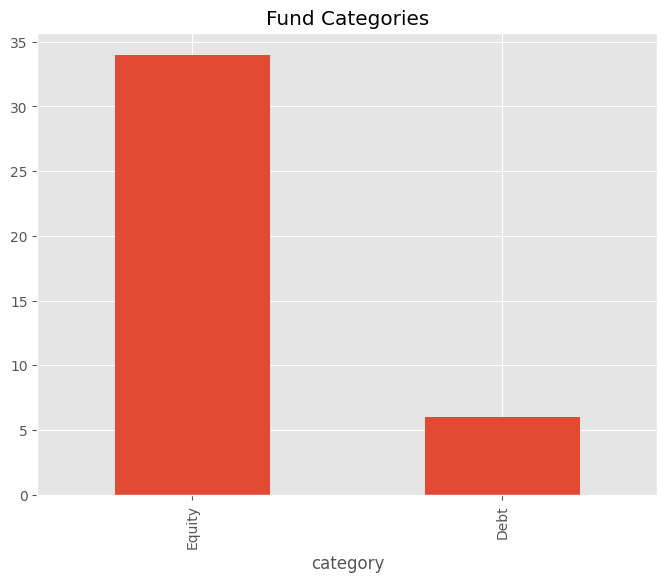

In [13]:
plt.figure(figsize=(8,6))

fund["category"].value_counts().plot(
    kind="bar"
)

plt.title("Fund Categories")
plt.show()

Chart 6 – Investor Age Distribution (Pie Chart)

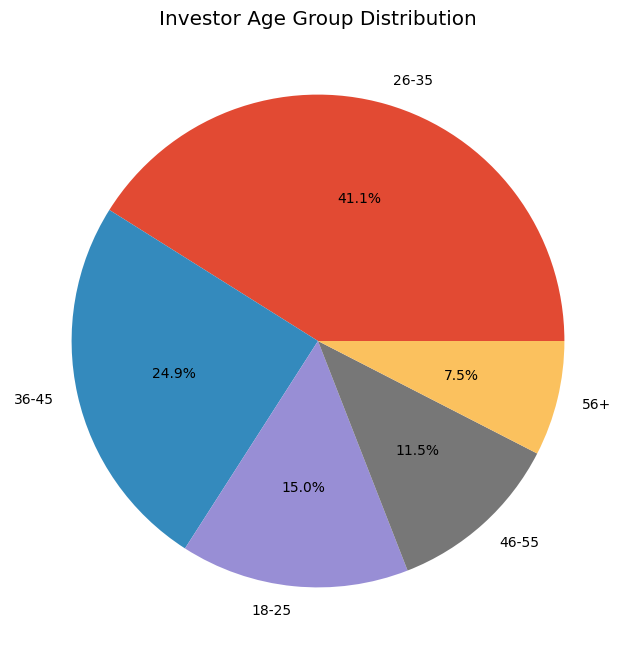

In [15]:
age_counts = txn["age_group"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)
plt.title("Investor Age Group Distribution")
plt.show()

Chart 7 – Gender Split

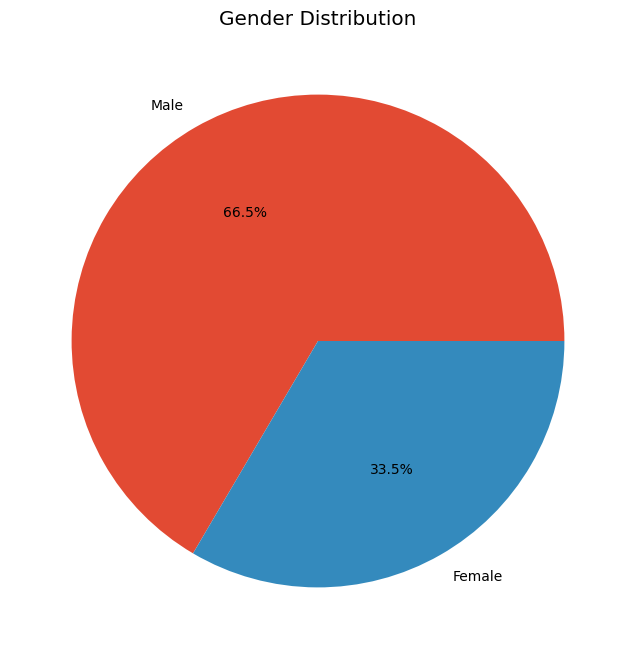

In [16]:
gender_counts = txn["gender"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)
plt.title("Gender Distribution")
plt.show()

Chart 8 – State-wise SIP Amo

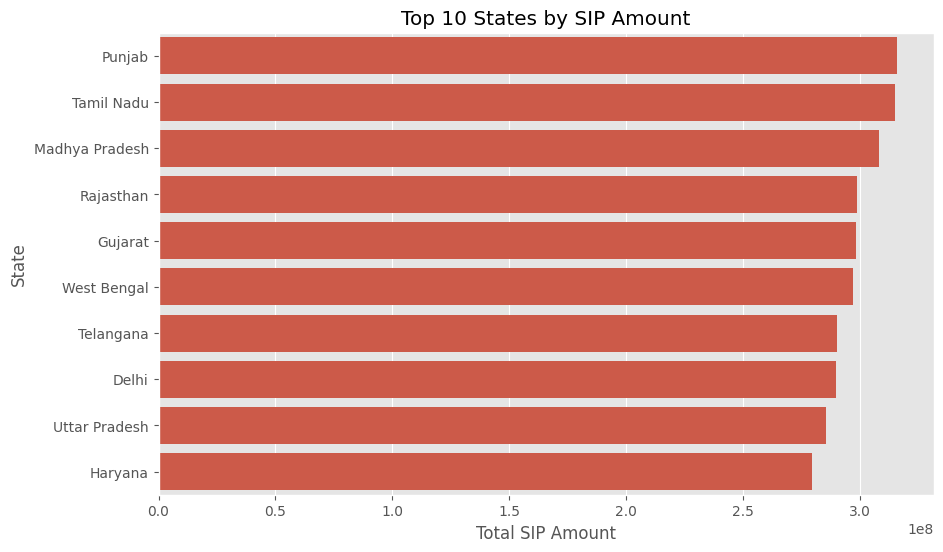

In [17]:
state_sip = (
    txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Top 10 States by SIP Amount")
plt.xlabel("Total SIP Amount")
plt.ylabel("State")
plt.show()

Chart 9 – Correlation Heatmap

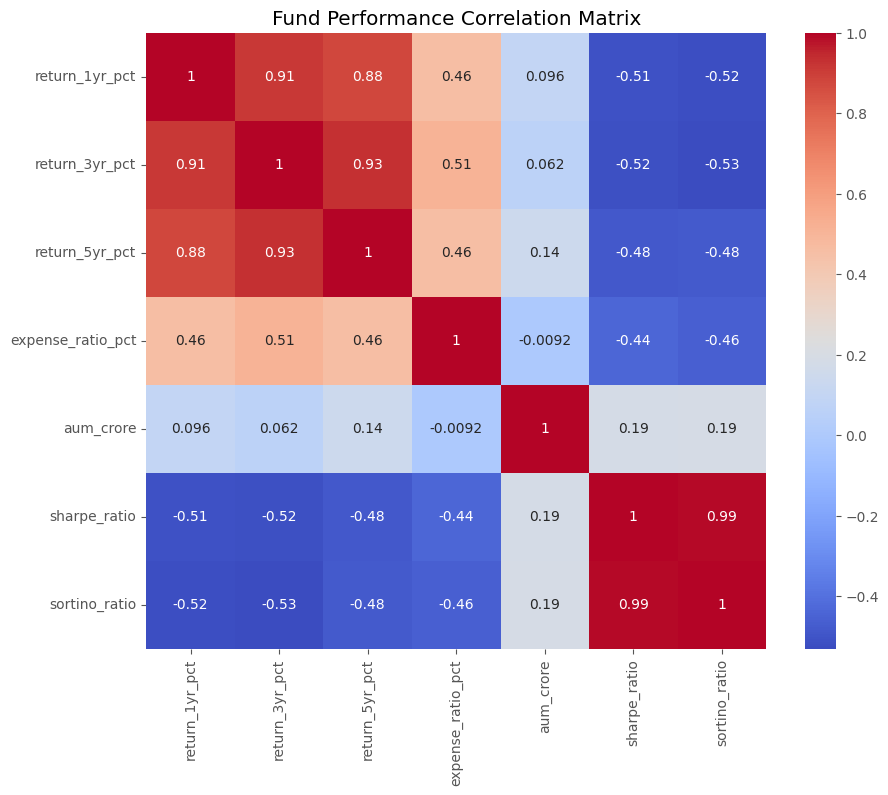

In [18]:
corr_cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "expense_ratio_pct",
    "aum_crore",
    "sharpe_ratio",
    "sortino_ratio"
]

corr_matrix = perf[corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Fund Performance Correlation Matrix")
plt.show()

Chart 10 – Expense Ratio Distribution

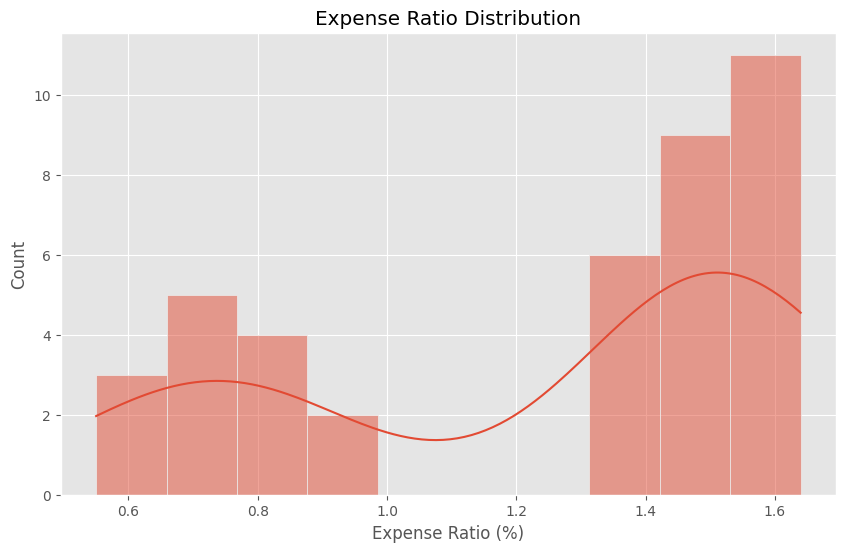

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    perf["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.show()

Chart 11 – Risk Grade Distribution

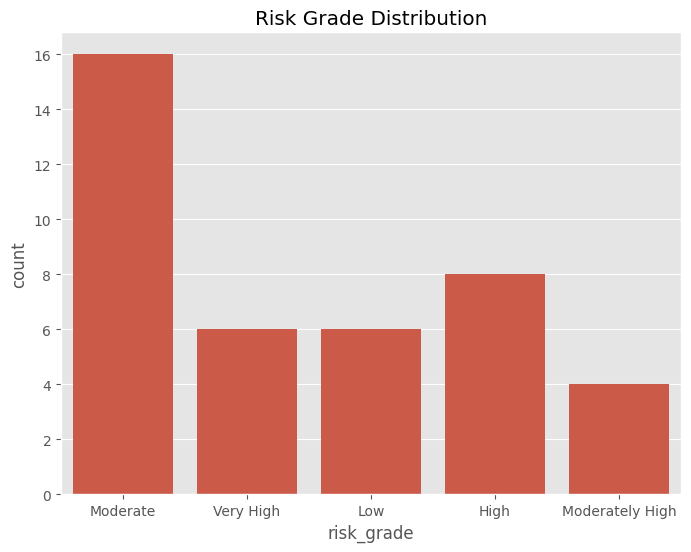

In [20]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=perf,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")
plt.show()

Chart 12 – Fund House Distribution

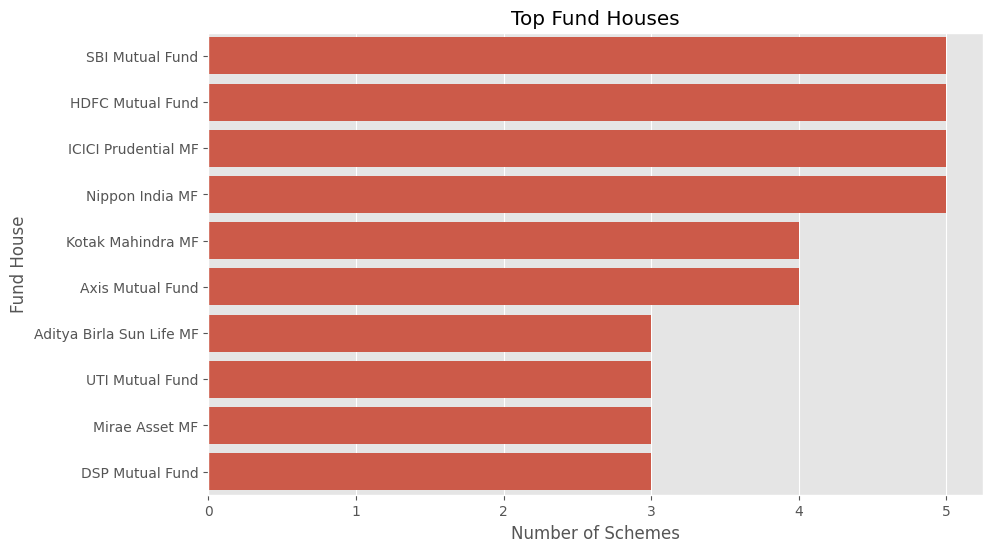

In [21]:
top_funds = (
    fund["fund_house"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_funds.values,
    y=top_funds.index
)

plt.title("Top Fund Houses")
plt.xlabel("Number of Schemes")
plt.ylabel("Fund House")
plt.show()

Chart 13 – Risk vs Return Scatter Plot

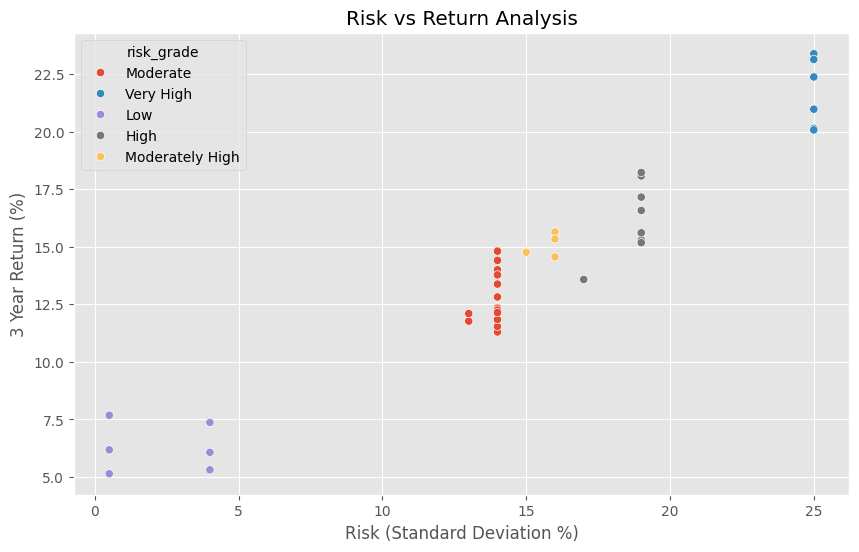

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=perf,
    x="std_dev_ann_pct",
    y="return_3yr_pct",
    hue="risk_grade"
)

plt.title("Risk vs Return Analysis")
plt.xlabel("Risk (Standard Deviation %)")
plt.ylabel("3 Year Return (%)")
plt.show()

Chart 14 – AUM Distribution by Category

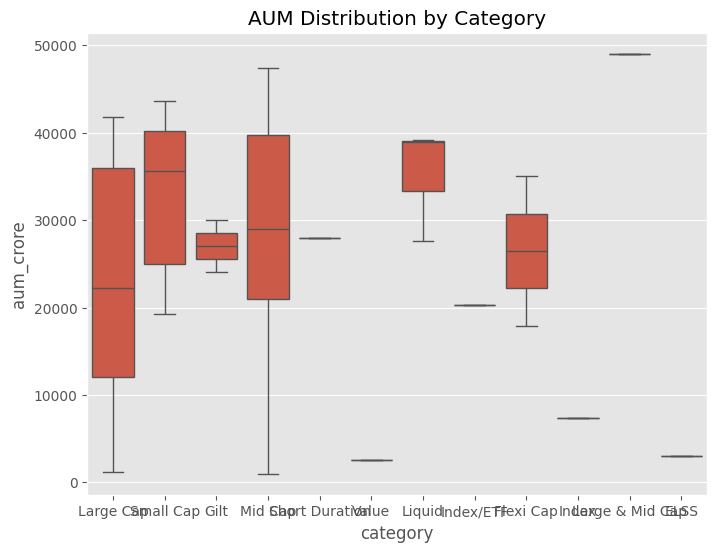

In [23]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=perf,
    x="category",
    y="aum_crore"
)

plt.title("AUM Distribution by Category")
plt.show()

Chart 15 – Return Distribution

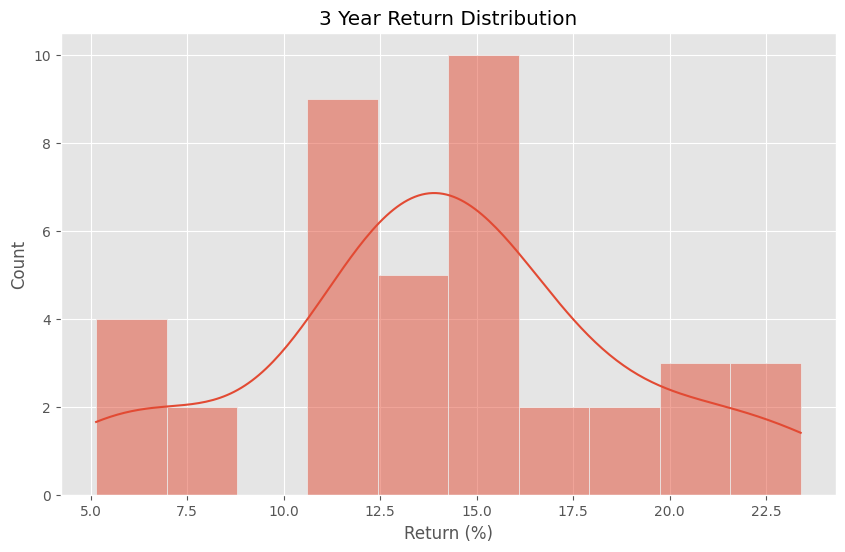

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    perf["return_3yr_pct"],
    bins=10,
    kde=True
)

plt.title("3 Year Return Distribution")
plt.xlabel("Return (%)")
plt.show()

# Key EDA Findings

1. NAV values showed a consistent upward trend across most schemes from 2022–2026.

2. One scheme significantly outperformed others in average NAV, indicating strong historical growth.

3. SIP AUM increased steadily between 2022 and 2025, showing growing investor participation.

4. New SIP account creation remained stable with a notable spike during 2025.

5. Equity funds dominate the dataset, accounting for the majority of available schemes.

6. Investors aged 26–35 form the largest investor segment.

7. Male investors contribute nearly twice the participation of female investors.

8. Punjab and Tamil Nadu recorded the highest SIP investment amounts.

9. Expense ratios are concentrated within a narrow range, indicating consistent fund management costs.

10. Higher-risk funds generally exhibit higher return potential, confirming the risk-return relationship.